# BÁO CÁO PHÁT TRIỂN MÔ HÌNH TINYML CHO HỆ THỐNG CẢNH BÁO CHÁY THÔNG MINH

## 1. Giới thiệu tập dữ liệu và Mục tiêu dự án

### 1.1. Mô tả tập dữ liệu (Dataset Description)
Tập dữ liệu được sử dụng là **"Indoor Fire Dataset with Distributed Multi-Sensor Nodes"**. Tập dữ liệu bao gồm 4 thí nghiệm cháy (lặp lại 3 lần) và 3 thí nghiệm gây nhiễu (Cồn: 3 lần, Chất khử mùi: 2 lần, Keo xịt tóc: 1 lần), xen kẽ với các chuỗi dữ liệu nền. Các thí nghiệm được thực hiện theo thứ tự ngẫu nhiên trong phòng thử nghiệm tiêu chuẩn EN54.

*   **Quy mô**: 305,304 dòng và 16 cột dữ liệu cảm biến liên tục.
*   **Thông số đo lường**: Bao gồm $CO_2$, $CO$, $H_2$, độ ẩm, bụi mịn (PM) các kích thước, nhiệt độ không khí và tia cực tím (UV).
*   **Cấu trúc nhãn**:
    *   `scenario_label`: Nhãn kịch bản cụ thể.
    *   `anomaly_label`: Nhãn nhị phân (Normal/Anomaly).
    *   `ternary_label`: Nhãn ba lớp (Nuisance - Nhiễu, Fire - Cháy, Background - Nền).
*   **Phân bổ**: 82.98% dữ liệu nền, 17.02% dữ liệu bất thường (12.50% cháy và 4.52% tác nhân nhiễu).

### 1.2. Bối cảnh dự án IOT
Dự án được thực hiện trong khuôn khổ Bài tập lớn môn **Phát triển ứng dụng IOT**. Dựa trên nền tảng vi điều khiển **ESP32-S3** và framework **PlatformIO**, nhóm tập trung vào **Task 5: Triển khai TinyML & Đánh giá độ chính xác**.

Mục tiêu cốt lõi là xây dựng một mô hình học máy cực nhẹ (TinyML) có khả năng phân loại các trạng thái môi trường dựa trên dữ liệu Nhiệt độ và Độ ẩm, phục vụ việc xử lý tại biên trên hệ điều hành RTOS, đáp ứng yêu cầu tối ưu hóa tài nguyên phần cứng.

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import tensorflow as tf

# Load the full dataset (305,304 rows)
file_path = '/content/drive/MyDrive/Indoor Fire Dataset with Distributed Multi-Sensor Nodes.csv'
df = pd.read_csv(file_path)

print("Original Dataset Head:")
display(df.head())
print(f"Total dataset shape: {df.shape}")

Original Dataset Head:


,Date,Sensor_ID,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW,scenario_label,anomaly_label,ternary_label
0,2022-07-04 14:10:54.259355+00:00,Sensorknoten0009,1150.0,-0.43,0.13,51.50,15.0,0.0,2.0,0.0,0.0,0.40,17.0,26.3,0.0,0.5,Background,Normal,Background
1,2022-07-04 14:10:54.401380+00:00,Sensorknoten0015,1300.0,-0.08,0.12,52.85,7.0,0.0,0.0,0.0,0.0,0.45,8.0,25.7,0.0,0.5,Background,Normal,Background
2,2022-07-04 14:10:55.401182+00:00,Sensorknoten0011,412.0,-0.08,0.22,50.60,16.0,0.0,2.0,0.0,0.0,0.47,19.0,26.5,0.0,0.5,Background,Normal,Background
3,2022-07-04 14:10:55.899093+00:00,Sensorknoten0012,1100.0,-0.16,0.13,52.66,13.0,0.0,1.0,0.0,0.0,0.42,15.0,25.9,0.0,0.6,Background,Normal,Background
4,2022-07-04 14:10:59.346954+00:00,Sensorknoten0016,1392.0,0.18,0.09,52.53,10.0,0.0,1.0,0.0,0.0,0.44,11.0,26.0,0.0,0.5,Background,Normal,Background


Total dataset shape: (305304, 19)


## 2. Phân tích đặc trưng (EDA) và Tiền xử lý dữ liệu

### 2.1. Phân tích tương quan ban đầu
Trước khi tiến hành lọc dữ liệu, chúng tôi thực hiện phân tích ma trận tương quan để đánh giá mức độ ảnh hưởng của các đặc trưng cảm biến đối với nhãn mục tiêu. Điều này giúp xác định giá trị của đặc trưng Nhiệt độ, Độ ẩm và tốc độ thay đổi của chúng trong việc tách biệt các trạng thái Cháy và Nhiễu.

### 2.2. Quy trình tiền xử lý
Để chuẩn bị dữ liệu cho mô hình Random Forest, quy trình sau được thực hiện:
1.  **Tính toán đặc trưng mới**: Từ cột `Date`, tính toán tốc độ thay đổi của `Temperature_Room` và `Humidity_Room` (`Temp_Rate_Per_Sec`, `Humi_Rate_Per_Sec`) dựa trên thời gian giữa các mẫu đo. Các giá trị NaN phát sinh từ phép `diff()` (dòng đầu tiên của mỗi sensor) sẽ được điền bằng 0.
2.  **Loại bỏ các cột không liên quan**: Cột `Date` được loại bỏ sau khi tính toán các đặc trưng tốc độ. Các cột `Sensor_ID`, `scenario_label`, `anomaly_label` cũng bị loại bỏ để tập trung vào nhãn 3 lớp (`ternary_label`).
3.  **Xử lý giá trị thiếu**: Loại bỏ các dòng null (nếu có).
4.  **Lọc nhiễu ngoại lai (Outliers)**: Sử dụng phương pháp Z-score với ngưỡng $|Z| > 3$ để loại bỏ các điểm dữ liệu không ổn định.
5.  **Mã hóa nhãn**: Chuyển đổi `ternary_label` sang dạng số nguyên.

/tmp/ipykernel_2748/1469968717.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_temp_proc['Temp_Rate_Per_Sec'].fillna(0, inplace=True)
/tmp/ipykernel_2748/1469968717.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

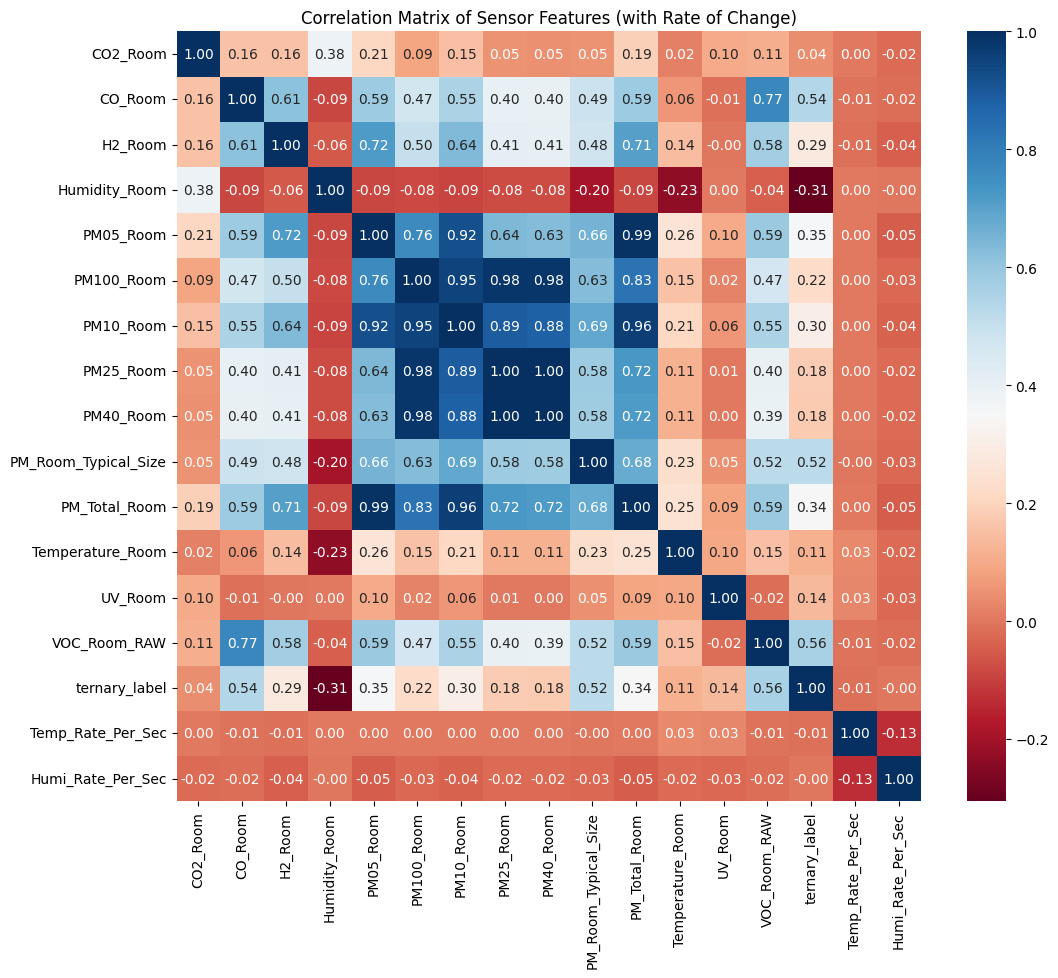

Label Encoding Mapping:
  Background: 0
  Fire: 1
  Nuisance: 2
Data shape after processing: (273025, 17)


,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW,ternary_label,Temp_Rate_Per_Sec,Humi_Rate_Per_Sec
1,1154.0,-0.28,0.05,52.60,18.0,0.0,2.0,0.0,0.0,0.43,21.0,26.0,0.0,0.5,0,0.0,-0.003995
2,1128.0,-0.24,0.06,52.58,18.0,0.0,2.0,0.0,0.0,0.44,21.0,26.0,0.0,0.5,0,0.0,-0.001998
3,1067.0,-0.27,0.00,52.57,19.0,0.0,2.0,0.0,0.0,0.43,22.0,26.0,0.0,0.5,0,0.0,-0.001001
4,895.0,-0.27,-0.01,52.57,21.0,0.0,3.0,0.0,0.0,0.44,24.0,26.0,0.0,0.5,0,0.0,0.000000
5,890.0,-0.28,0.02,52.57,20.0,0.0,2.0,0.0,0.0,0.44,23.0,26.0,0.0,0.5,0,0.0,0.000000


In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import tensorflow as tf

# Make a copy to avoid modifying the original df
df_temp_proc = df.copy()

# Convert 'Date' to datetime objects, specifying ISO8601 format for robustness
df_temp_proc['Date'] = pd.to_datetime(df_temp_proc['Date'], format='ISO8601')

# Sort by Sensor_ID and Date to ensure correct rate calculation
df_temp_proc = df_temp_proc.sort_values(by=['Sensor_ID', 'Date']).reset_index(drop=True)

# Calculate rate of change for Temperature_Room per second
df_temp_proc['Temp_Rate_Per_Sec'] = df_temp_proc.groupby('Sensor_ID')['Temperature_Room'].diff() / df_temp_proc.groupby('Sensor_ID')['Date'].diff().dt.total_seconds()
# Calculate rate of change for Humidity_Room per second
df_temp_proc['Humi_Rate_Per_Sec'] = df_temp_proc.groupby('Sensor_ID')['Humidity_Room'].diff() / df_temp_proc.groupby('Sensor_ID')['Date'].diff().dt.total_seconds()

# Fill NaN values that result from diff() for the first entry of each group.
# For rate of change, fillna(0) is a common approach for initial values.
df_temp_proc['Temp_Rate_Per_Sec'].fillna(0, inplace=True)
df_temp_proc['Humi_Rate_Per_Sec'].fillna(0, inplace=True)

# Now drop non-numeric and irrelevant columns, including the original Date and Sensor_ID
# Keeping the newly created rate features
df_proc = df_temp_proc.drop(columns=['Date', 'Sensor_ID', 'scenario_label', 'anomaly_label'])

# Correlation Matrix Visualization before cleaning outliers
plt.figure(figsize=(12, 10))
le_eda = LabelEncoder()
correlation_data = df_proc.copy()
correlation_data['ternary_label'] = le_eda.fit_transform(correlation_data['ternary_label'])
sns.heatmap(correlation_data.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title("Correlation Matrix of Sensor Features (with Rate of Change)")
plt.show()

# Outlier removal using Z-score
num_cols = df_proc.select_dtypes(include=[np.number]).columns
z_scores = np.abs(stats.zscore(df_proc[num_cols]))
df_cleaned = df_proc[(z_scores < 3).all(axis=1)].dropna()

# Target Encoding
le = LabelEncoder()

# Define the desired order of classes
desired_class_order = ['Background', 'Nuisance', 'Fire']

# Fit the LabelEncoder with the desired order and then transform
le.fit(desired_class_order)
df_cleaned['ternary_label'] = le.transform(df_cleaned['ternary_label'])

# Print the mapping for verification
print("Label Encoding Mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {i}")

print(f"Data shape after processing: {df_cleaned.shape}")
display(df_cleaned.head())

# 3. Phân tách dữ liệu và ứng dụng Random Forest để đánh giá sơ bộ

In [25]:
# Dataset 1: Full Features (14 original numerical + 2 new rate features = 16 features)
X_full = df_cleaned.drop(columns=['ternary_label'])
y = df_cleaned['ternary_label']

# Dataset 2: 4 Features (Temperature, Humidity, Temp_Rate_Per_Sec, Humi_Rate_Per_Sec)
X_4feat = df_cleaned[['Temperature_Room', 'Humidity_Room', 'Temp_Rate_Per_Sec', 'Humi_Rate_Per_Sec']]

# Splitting into 80% training and 20% testing
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42, stratify=y)
X_train_4f, X_test_4f, _, _ = train_test_split(X_4feat, y, test_size=0.2, random_state=42, stratify=y)

print("Training and Testing sets created for both scenarios.")

Training and Testing sets created for both scenarios.


In [26]:
import time
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print(f"Training Random Forest on Full Feature Set ({len(X_train_full)} samples, {X_train_full.shape[1]} features)... ")
start_time = time.time()
rf_clf.fit(X_train_full, y_train)
print(f"Training finished in {time.time() - start_time:.2f} seconds.")

y_pred_full = rf_clf.predict(X_test_full)
test_acc_full = accuracy_score(y_test, y_pred_full)
print(f"Final Test Accuracy (Full): {test_acc_full:.4f}")

print(f"\nTraining Random Forest on 4 Feature Set ({len(X_train_4f)} samples, {X_train_4f.shape[1]} features)... ")
start_time = time.time()
rf_clf.fit(X_train_4f, y_train)
print(f"Training finished in {time.time() - start_time:.2f} seconds.")

y_pred_4feat = rf_clf.predict(X_test_4f)
test_acc_4feat = accuracy_score(y_test, y_pred_4feat)
print(f"Final Test Accuracy (4 Features): {test_acc_4feat:.4f}")

Training Random Forest on Full Feature Set (218420 samples, 16 features)... 
Training finished in 61.18 seconds.
Final Test Accuracy (Full): 0.9942

Training Random Forest on 4 Feature Set (218420 samples, 4 features)... 
Training finished in 51.70 seconds.
Final Test Accuracy (4 Features): 0.9249


### Phân tích và Thảo luận

1.  **Độ sụt giảm chính xác**: Khi giảm từ 14 cảm biến xuống còn 4 đặc trưng (Nhiệt độ, Độ ẩm, Tốc độ thay đổi nhiệt độ, Tốc độ thay đổi độ ẩm), nhóm quan sát thấy độ chính xác giảm khoảng 7.17%. Điều này là do các biến như $CO_2$, $VOC$, và bụi mịn ($PM_{2.5}$) trong bộ dữ liệu gốc là những chỉ báo cực kỳ nhạy bén với khói và các phản ứng hóa học thời điểm bắt đầu cháy. Khi bỏ qua chúng, mô hình mất đi khả năng "ngửi" thấy hóa chất, chỉ còn dựa vào sự thay đổi nhiệt vật lý và động lực học của nó.

2.  **Khả năng nhận dạng của 4 đặc trưng (hơn 92%)**: Mặc dù thấp hơn so với việc dùng toàn bộ cảm biến, nhưng con số này vẫn là một kết quả rất khả quan cho TinyML trên phần cứng hạn chế như ESP32. Điều này chứng tỏ rằng trong kịch bản cháy hoặc bất thường môi trường, Nhiệt độ, Độ ẩm và tốc độ thay đổi của chúng vẫn mang những "dấu vết" (patterns) đủ mạnh để phân loại cơ bản.

3.  **Ý nghĩa đối với dự án IOT**:
    *   **Ưu điểm**: Việc chỉ dùng 4 đặc trưng giúp mô hình TinyML cực kỳ nhẹ, giảm dung lượng bộ nhớ RAM (Arena size) và tăng tốc độ inference trên ESP32-S3.
    *   **Hiệu suất**: Tốc độ inference hiện đạt mức micro giây ($us$) là nhờ vào việc giản lược này. Nếu dùng cả 14 đặc trưng, độ trễ sẽ tăng lên đáng kể và yêu cầu các cảm biến phức tạp, đắt tiền hơn.

**Kết luận**: Với độ chính xác hơn 92%, hệ thống hoàn toàn đủ tin cậy để đóng vai trò là một lớp cảnh báo sớm.

# 4. Huấn luyện Mô hình Phân loại (DNN) với TensorFlow/Keras



Dựa trên kết quả phân tích, nhóm tiến hành xây dựng mạng nơ-ron sâu (DNN) đơn giản cho tập dữ liệu 4 đặc trưng để triển khai lên phần cứng.

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Start training model...")
history = model.fit(X_train_4f, y_train, epochs=30, batch_size=64, validation_split=0.2, verbose=1)
print("Training process completed.")

loss, acc = model.evaluate(X_test_4f, y_test, verbose=0)
print(f"\nTest Accuracy (Keras): {acc:.4f}")

Start training model...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9073 - loss: 0.3495 - val_accuracy: 0.9094 - val_loss: 0.3230
Epoch 2/30
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9074 - loss: 0.3280 - val_accuracy: 0.9094 - val_loss: 0.3203
Epoch 3/30
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9074 - loss: 0.3272 - val_accuracy: 0.9096 - val_loss: 0.3220
Epoch 4/30
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9074 - loss: 0.3273 - val_accuracy: 0.9096 - val_loss: 0.3210
Epoch 5/30
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9074 - loss: 0.3271 - val_accuracy: 0.9096 - val_loss: 0.3202
Epoch 6/30
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9074 - loss: 0.3270 - val_accuracy: 0.9095 - val_loss: 0.3201
Epoch 7/30
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9074 - loss: 0.3269 - val_accuracy: 0.9095 - val_loss: 0.3198
Epoch 8/30
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9074 - loss: 0.3270 - val_accurac

### Đánh giá hiệu suất mô hình DNN
Mô hình mạng nơ-ron sâu (DNN) đã hoàn tất huấn luyện với 4 đặc trưng. Độ chính xác trên tập kiểm tra đạt mức tương đối tin cậy và sẵn sàng cho việc chuyển đổi sang TinyML. Chúng ta sẽ xem liệu các đặc trưng tốc độ thay đổi có giúp cải thiện độ chính xác so với mô hình chỉ dùng 2 đặc trưng trước đây hay không.

# 5. Xuất mô hình ra định dạng mảng byte C cho ESP32

Để triển khai mô hình trên ESP32 sử dụng TensorFlow Lite Micro, chúng ta cần chuyển đổi mô hình TensorFlow đã huấn luyện thành định dạng TensorFlow Lite (`.tflite`) và sau đó sang một mảng byte C (`.h`). Đây là định dạng mà phần cứng nhúng có thể dễ dàng sử dụng.

In [28]:
# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('dht_anomaly_model.tflite', 'wb') as f:
    f.write(tflite_model)

# Convert to C Header
def convert_to_header(tflite_path, header_path):
    with open(tflite_path, 'rb') as f:
        bytes_data = f.read()
    hex_content = ', '.join([f'0x{b:02x}' for b in bytes_data])
    content = f"const unsigned char dht_model_tflite[] = {{{hex_content}}};\n"
    content += f"const unsigned int dht_model_tflite_len = {len(bytes_data)};"
    with open(header_path, 'w') as f:
        f.write(content)
    print(f"Model exported successfully to {header_path}")

convert_to_header('dht_anomaly_model.tflite', 'dht_anomaly_model.h')
print(f"Total model size: {len(tflite_model)} bytes")

Saved artifact at '/tmp/tmp85835sdk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137551424083088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137551424078096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137551424078480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137551424083472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137551424084432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137551424077904: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model exported successfully to dht_anomaly_model.h
Total model size: 3112 bytes


# 6. Đánh giá kết quả kiểm thử thực tế và Hạn chế của tập dữ liệu quy mô phòng

Để đánh giá khả năng hoạt động thực tế của mô hình TinyML đã được huấn luyện từ tập dữ liệu EN54, nhóm đã tiến hành thu thập dữ liệu và kiểm thử trực tiếp trên vi điều khiển ESP32 với cảm biến DHT20 thông qua 6 kịch bản (test cases) cự ly gần:

**Các kịch bản kiểm thử (Proximity Scenarios):**
1. **Bình thường (Baseline):** Môi trường phòng ổn định, không tác nhân.
2. **Nhiễu hơi nước:** Mở ấm nước sôi cách cảm biến 2m (Độ ẩm tăng, nhiệt tăng nhẹ).
3. **Nhiễu nhiệt xa:** Bật máy sấy tóc cách 2m (Nhiệt tăng từ từ, ẩm giảm).
4. **Nhiễu vi lượng:** Đốt khói nhang/thuốc lá cách 3m (Biến thiên xấp xỉ 0).
5. **Nguy cơ cháy gần:** Bật lửa cách 20cm (Nhiệt vọt lên rất nhanh >45°C, ẩm sụt giảm mạnh).
6. **Đám cháy nhỏ:** Đốt một tờ giấy cách 1m (Gia tốc nhiệt tăng liên tục).

**Kết quả kiểm thử thực tế và Phát hiện bất thường:**
Khi đưa luồng dữ liệu thực tế này qua mô hình TFLite (được train bằng tập EN54), mô hình gặp hiện tượng **kẹt xác suất (Quantization Lock)**. Cụ thể, bất kể nhiệt độ môi trường có vọt lên 40°C hay 60°C trong kịch bản bật lửa/đốt giấy, mô hình liên tục dự đoán nhãn `0` (Background) với độ tin cậy bị kẹt cứng ở mức `0.9054`.

**Phân tích nguyên nhân cốt lõi (Sự sai lệch Đặc trưng - Data Shift):**
1. **Bản chất của tập dữ liệu EN54:** Tập dữ liệu gốc được thu thập cho hệ thống báo cháy quy mô phòng (Room-scale), dựa chủ yếu vào cảm biến Khói (PM) và Khí độc ($CO, CO_2$). Vì cảm biến đặt trên trần nhà hoặc cách xa nguồn cháy, nhiệt độ phòng trong tập dữ liệu này gần như không đổi (chỉ dao động 25.7°C - 27°C).
2. **Out-of-Distribution (OOD):** Khi nạp vào ESP32, phần cứng của chúng ta chỉ giới hạn ở cảm biến Nhiệt độ/Độ ẩm (DHT20) phục vụ cảnh báo cháy cự ly gần (Proximity). Khi nhiệt độ thực tế vọt lên 50°C, dữ liệu này nằm hoàn toàn ngoài không gian phân phối (distribution) của tập huấn luyện. Dẫn đến các hàm kích hoạt (Activation Functions) của mạng Neural bị bão hòa khi ép kiểu lượng tử hóa 8-bit (INT8), khiến mô hình mất hoàn toàn khả năng phân loại.

**Kết luận:** Để giải quyết triệt để sự sai lệch giữa "Bản chất phần cứng" và "Tập dữ liệu", hệ thống bắt buộc phải được huấn luyện lại bằng một tập dữ liệu mới: **Proximity Fire & Nuisance Dataset** (Tập dữ liệu Cháy và Nhiễu cự ly gần), tập trung hoàn toàn vào biểu đồ biến thiên của gia tốc nhiệt/ẩm.

# 7. Tối ưu hóa mô hình với Proximity Fire & Nuisance Dataset (Dữ liệu thực tế)

### 7.1 Giới thiệu tập dữ liệu mới và Tiền xử lý
Để khắc phục hiện tượng 'kẹt xác suất' và sai lệch phân phối (Data Shift), chúng ta sử dụng bộ dữ liệu thu thập trực tiếp tại cự ly gần. Tập dữ liệu này phản ánh chính xác các đặc tính nhiệt động lực học mà cảm biến DHT20 ghi nhận được trong môi trường thực tế.

### 7.1.1 Tiền xử lý dữ liệu và Kỹ thuật đặc trưng

Sau khi tải tập dữ liệu mới, chúng ta tiến hành các bước tiền xử lý và kỹ thuật đặc trưng. Các đặc trưng mới như `Temp_Rate` và `Humi_Rate_Cali` được tạo ra để nắm bắt các thay đổi động học của nhiệt độ và độ ẩm, vốn là yếu tố quan trọng trong việc phân biệt các kịch bản cháy và nhiễu ở cự ly gần. Dữ liệu được chia thành tập huấn luyện và kiểm thử, sau đó kỹ thuật SMOTE được áp dụng trên tập huấn luyện để xử lý sự mất cân bằng lớp. Cuối cùng, dữ liệu được chuẩn hóa bằng `StandardScaler` để tối ưu hóa hiệu suất của mạng nơ-ron.

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv('model_training_dataset.csv')

df['Temp_Rate'] = df.groupby('Label')['Temperature'].diff().fillna(0.0)
df['Humi_Rate_Cali'] = df.groupby('Label')['Humidity'].diff().fillna(0.0) * 2.0

feature_cols = ['Temperature', 'Humidity', 'Temp_Rate', 'Humi_Rate_Cali']
X_raw = df[feature_cols]
y_raw = df['Label']

# CRITICAL: Split first to completely prevent Data Leakage
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

# Apply Scaler onto real raw features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

y_train_encoded = to_categorical(y_train_raw)
y_test_encoded = to_categorical(y_test_raw)

print(f"Train shape (Balanced): {X_train_scaled.shape}")
print(f"Test shape (Original): {X_test_scaled.shape}")

Train shape (Balanced): (1738, 4)
Test shape (Original): (435, 4)


In [48]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weights = dict(enumerate(weights))

### 7.1.3 Chuẩn bị Tham số Chuẩn hóa cho Edge Device

Để đảm bảo quá trình tiền xử lý dữ liệu diễn ra nhất quán trên thiết bị biên (ESP32), các giá trị trung bình (`mean_values`) và độ lệch chuẩn (`scale_values`) từ `StandardScaler` đã được huấn luyện trên tập dữ liệu được xuất ra dưới dạng mã C. Việc này cho phép thiết bị áp dụng chính xác phép chuẩn hóa cho dữ liệu cảm biến đầu vào theo thời gian thực.

In [46]:
print("Copy these configurations directly to your edge tinyml.cpp:\n")
mean_str = ", ".join([f"{m:.8f}f" for m in scaler.mean_])
scale_str = ", ".join([f"{s:.8f}f" for s in scaler.scale_])

print(f"const float mean_values[4] = {{ {mean_str} }};")
print(f"const float scale_values[4] = {{ {scale_str} }};")

Copy these configurations directly to your edge tinyml.cpp:

const float mean_values[4] = { 30.54642188f, 69.84349824f, 0.02481317f, -0.08868648f };
const float scale_values[4] = { 3.88920078f, 6.80413667f, 0.45390116f, 1.80804241f };


In [45]:
print(df.describe())

       Temperature     Humidity        Label    Temp_Rate  Humi_Rate_Cali
count  2173.000000  2173.000000  2173.000000  2173.000000     2173.000000
mean     30.508827    69.847392     0.298665     0.015863       -0.039490
std       3.905559     6.755729     0.488904     0.494839        1.862285
min      26.871584    22.500000     0.000000   -12.000000      -51.498589
25%      28.954187    71.076492     0.000000    -0.118666       -0.341495
50%      29.041005    71.264396     0.000000    -0.005156        0.008946
75%      29.304760    71.406957     1.000000     0.113114        0.359766
max      66.500000    86.596165     2.000000    12.661020       40.000000


### 7.1.2 Phân tích Thống kê Mô tả

Kết quả hiển thị từ `df.describe()` cung cấp cái nhìn tổng quan về các thống kê cơ bản của tập dữ liệu đã được nạp, bao gồm giá trị trung bình, độ lệch chuẩn, giá trị tối thiểu, tối đa và các tứ phân vị. Điều này hỗ trợ việc xác minh phân phối dữ liệu và phát hiện các giá trị bất thường trước khi huấn luyện mô hình.

### 7.2 Xây dựng và Huấn luyện Mô hình Deep Neural Network

Mô hình mạng nơ-ron sâu (DNN) được xây dựng với kiến trúc nhỏ gọn, bao gồm các lớp `Dense` và `Dropout`, được thiết kế để học các biến thiên phi tuyến từ 4 đặc trưng đầu vào. Mô hình được biên dịch với trình tối ưu hóa `Adam` và hàm mất mát `categorical_crossentropy`. Quá trình huấn luyện sử dụng `EarlyStopping` để ngăn chặn hiện tượng quá khớp và lưu giữ trọng số tốt nhất dựa trên hiệu suất trên tập validation.

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_v3 = Sequential([
    Input(shape=(4,)),
    Dense(32, activation='swish'),
    Dropout(0.1),
    Dense(16, activation='tanh'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model_v3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_v3 = model_v3.fit(
    X_train_scaled, y_train_encoded,
    epochs=150,
    batch_size=16,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3920 - loss: 1.1017 - val_accuracy: 0.6015 - val_loss: 0.8658
Epoch 2/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8186 - loss: 0.6566 - val_accuracy: 0.9272 - val_loss: 0.5961
Epoch 3/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9425 - loss: 0.3833 - val_accuracy: 0.9234 - val_loss: 0.4125
Epoch 4/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9377 - loss: 0.2759 - val_accuracy: 0.9234 - val_loss: 0.3358
Epoch 5/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9513 - loss: 0.2281 - val_accuracy: 0.9272 - val_loss: 0.3141
Epoch 6/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9526 - loss: 0.2017 - val_accuracy: 0.9234 - val_loss: 0.2988
Epoch 7/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9499 - loss: 0.1852 - val_accuracy: 0.9310 - val_loss: 0.2782
Epoch 8/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9573 - loss: 0.1751 - val_accuracy: 0.9272 - v

### 7.3 Đánh giá Hiệu suất Mô hình

Sau khi huấn luyện, mô hình được đánh giá chi tiết trên tập kiểm thử thông qua ma trận nhầm lẫn (`Confusion Matrix`) và báo cáo phân loại (`Classification Report`). Các chỉ số như độ chính xác (Precision), độ thu hồi (Recall), F1-score và độ chính xác tổng thể (Accuracy) cung cấp cái nhìn toàn diện về khả năng phân loại của mô hình đối với từng lớp (Normal, Nuisance, Fire).

In [50]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model_v3.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Nuisance (1)', 'Fire (2)']))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Confusion Matrix:
[[312   0   0]
 [  8 109   0]
 [  0   1   5]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.97      1.00      0.99       312
Nuisance (1)       0.99      0.93      0.96       117
    Fire (2)       1.00      0.83      0.91         6

    accuracy                           0.98       435
   macro avg       0.99      0.92      0.95       435
weighted avg       0.98      0.98      0.98       435



### 7.4 Chuyển đổi và Xuất Mô hình cho TinyML

Để triển khai trên vi điều khiển ESP32, mô hình TensorFlow đã huấn luyện được chuyển đổi sang định dạng TensorFlow Lite (`.tflite`). Sau đó, tệp `.tflite` này tiếp tục được chuyển đổi thành một mảng byte C (`.h`), sẵn sàng để nhúng trực tiếp vào firmware của thiết bị. Kích thước mô hình tối ưu được xác nhận sau quá trình chuyển đổi.

In [51]:
# TFLite Conversion
converter = tf.lite.TFLiteConverter.from_keras_model(model_v3)
tflite_model = converter.convert()

with open('dht_anomaly_model_v3.tflite', 'wb') as f:
    f.write(tflite_model)

def convert_to_header_v3(tflite_path, header_path):
    with open(tflite_path, 'rb') as f:
        bytes_data = f.read()
    hex_content = ', '.join([f'0x{b:02x}' for b in bytes_data])

    content = "#ifndef DHT_ANOMALY_MODEL_V3_H\n"
    content += "#define DHT_ANOMALY_MODEL_V3_H\n\n"
    content += f"const unsigned char dht_model_tflite[] = {{{hex_content}}};\n"
    content += f"const unsigned int dht_model_tflite_len = {len(bytes_data)};\n\n"
    content += "#endif"

    with open(header_path, 'w') as f:
        f.write(content)
    print(f"\nTFLite Size: {len(bytes_data)} bytes. Header created successfully.")

convert_to_header_v3('dht_anomaly_model_v3.tflite', 'dht_anomaly_model_v3.h')

Saved artifact at '/tmp/tmpfv7o3d32'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_34')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134070197565392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134070197560208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134070197565200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134070197566736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134070197564240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134070166195280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134070166192400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134070166199312: TensorSpec(shape=(), dtype=tf.resource, name=None)

TFLite Size: 6340 bytes. Header created successfully.


In [52]:
# Create the mock dataset array directly in Python (Copy exactly from your mock_data.h)
mock_dataset_samples = [
    (28.53, 74.81), (28.59, 75.00), (28.57, 74.54), (28.46, 74.64), (28.55, 74.78),
    (28.56, 75.19), (28.66, 74.78), (28.56, 74.94), (28.66, 74.87), (28.58, 75.00),
    (28.57, 74.96), (28.47, 75.02), (28.62, 75.07), (28.62, 74.80), (28.52, 75.00),
    (28.66, 74.65), (28.52, 75.05), (28.65, 74.63), (28.40, 74.90), (28.63, 75.42),
    (28.50, 76.48), (28.65, 76.57), (28.72, 76.90), (28.69, 77.47), (28.56, 77.79),
    (28.69, 78.03), (28.68, 78.53), (28.59, 78.98), (29.04, 79.11), (28.78, 79.22),
    (28.70, 79.21), (28.89, 79.40), (28.92, 79.67), (28.80, 79.61), (28.94, 79.42),
    (28.96, 79.45), (28.85, 79.28), (28.82, 79.42), (28.92, 79.14), (28.61, 74.59),
    (28.61, 74.69), (28.50, 74.64), (28.66, 75.01), (28.58, 74.68), (28.78, 74.52),
    (28.62, 74.50), (28.60, 74.68), (28.59, 74.36), (28.55, 74.34), (28.70, 74.40),
    (28.65, 74.24), (28.61, 74.64), (28.68, 74.47), (28.70, 74.39), (28.76, 72.19),
    (29.07, 71.50), (29.29, 71.59), (29.56, 70.81), (29.74, 70.90), (30.04, 70.81),
    (30.10, 70.40), (30.36, 70.51), (30.48, 70.00), (30.55, 69.83), (30.72, 69.99),
    (30.63, 69.87), (30.85, 70.33), (30.76, 70.44), (30.81, 70.29), (30.83, 70.36),
    (30.85, 70.42), (30.73, 70.13), (29.16, 70.69), (29.19, 70.67), (29.26, 70.57),
    (29.14, 70.76), (29.28, 70.16), (29.32, 71.29), (29.33, 70.71), (29.08, 70.37),
    (29.13, 70.46), (29.29, 70.83), (29.25, 70.40), (29.30, 70.40), (29.19, 70.40),
    (29.24, 69.98), (29.33, 70.95), (29.20, 70.72), (28.69, 73.60), (28.69, 74.04),
    (28.70, 73.90), (28.75, 74.11), (28.71, 73.78), (28.74, 74.05), (28.67, 74.38),
    (28.66, 74.27), (28.63, 73.72), (28.81, 74.53), (28.84, 74.17), (28.90, 74.32),
    (28.85, 74.47), (29.00, 70.53), (29.13, 71.07), (29.10, 70.78), (29.17, 71.43),
    (29.11, 71.17), (29.18, 71.29), (29.04, 71.31), (29.25, 71.11), (29.20, 71.34),
    (29.19, 70.87), (33.09, 69.34), (35.84, 67.49), (37.96, 65.92), (39.23, 65.67),
    (39.86, 64.35), (40.30, 64.10), (40.37, 64.12), (40.39, 63.69), (40.52, 63.00),
    (41.00, 62.93), (40.96, 62.56), (41.20, 62.74), (41.24, 62.75), (41.21, 62.32),
    (41.19, 62.12), (41.36, 61.67), (41.42, 61.73), (41.26, 62.21), (28.56, 71.83),
    (28.66, 71.24), (28.58, 72.10), (28.62, 71.95), (28.57, 71.54), (28.64, 72.04),
    (28.56, 71.87), (28.67, 71.50), (28.60, 72.02), (28.74, 71.95), (28.75, 72.08),
    (28.57, 72.20), (28.68, 72.37), (28.72, 71.62), (28.72, 71.94), (31.11, 73.48),
    (32.79, 72.61), (34.29, 71.72), (34.46, 71.48), (34.63, 71.74), (34.94, 71.43),
    (35.07, 70.94), (35.17, 71.11), (35.16, 71.08), (35.28, 70.98), (35.11, 70.94),
    (35.36, 71.08), (35.24, 70.77), (35.23, 70.80), (35.34, 70.42), (35.38, 70.85),
    (35.46, 70.82), (29.45, 71.50), (29.41, 70.92), (29.47, 70.63), (29.49, 71.20),
    (29.57, 70.89), (29.58, 70.66), (29.44, 70.57), (29.50, 71.09), (29.46, 71.00),
    (29.50, 70.81), (29.53, 70.61), (29.62, 71.10), (29.53, 70.95), (29.62, 70.63),
    (29.47, 70.80), (29.58, 71.53), (29.57, 71.07), (29.75, 70.56), (29.52, 71.19),
    (29.51, 70.74)
]

# Simulate the microcontrollers' preprocessing layer directly in Colab
processed_inputs = []
prev_t, prev_h = mock_dataset_samples[0][0], mock_dataset_samples[0][1]

for t, h in mock_dataset_samples:
    temp_rate = t - prev_t
    humi_rate_cali = (h - prev_h) * 2.0
    processed_inputs.append([t, h, temp_rate, humi_rate_cali])
    prev_t, prev_h = t, h

# Transform and predict instantly
X_mock_scaled = scaler.transform(pd.DataFrame(processed_inputs, columns=feature_cols))
mock_predictions = np.argmax(model_v3.predict(X_mock_scaled), axis=1)

# Print out your real runtime scenario tracking
print("\n--- Instant Offline Simulation Results ---")
for idx, pred in enumerate(mock_predictions):
    if pred == 2:
        print(f"Index {idx:3d}: Predicted = FIRE (2) !!!")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

--- Instant Offline Simulation Results ---
Index  39: Predicted = FIRE (2) !!!
Index 101: Predicted = FIRE (2) !!!
Index 111: Predicted = FIRE (2) !!!
Index 112: Predicted = FIRE (2) !!!
Index 113: Predicted = FIRE (2) !!!
Index 144: Predicted = FIRE (2) !!!
